In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays
import joblib

In [2]:
df = pd.read_csv("C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/casa_7_clima.csv", parse_dates=True)
df = df.drop(columns=['fecha'])

df.rename(columns={'consumo_kWh': 'y', 'timestamp': 'ds'}, inplace=True)

# Exploración de Variables del Dataset
En esta sección, exploraremos las variables disponibles en el dataset para determinar cuáles son útiles para el modelo Prophet.

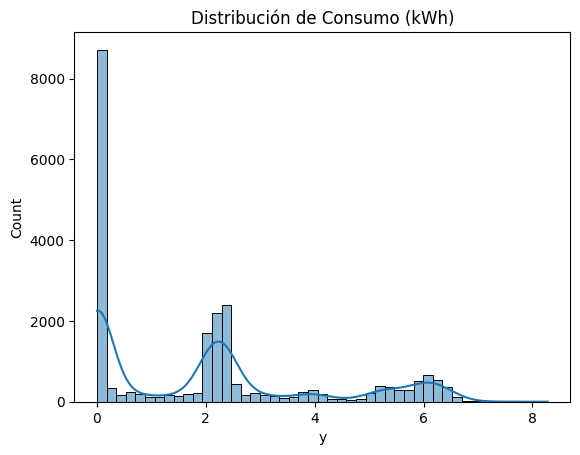

In [4]:
# Visualizar la distribución de la variable objetivo (consumo_kWh)
sns.histplot(df['y'], kde=True)
plt.title('Distribución de Consumo (kWh)')
plt.show()

# Análisis de Relaciones entre Variables
En esta sección, analizaremos las relaciones entre las variables del dataset para identificar cuáles son relevantes para el modelo Prophet.

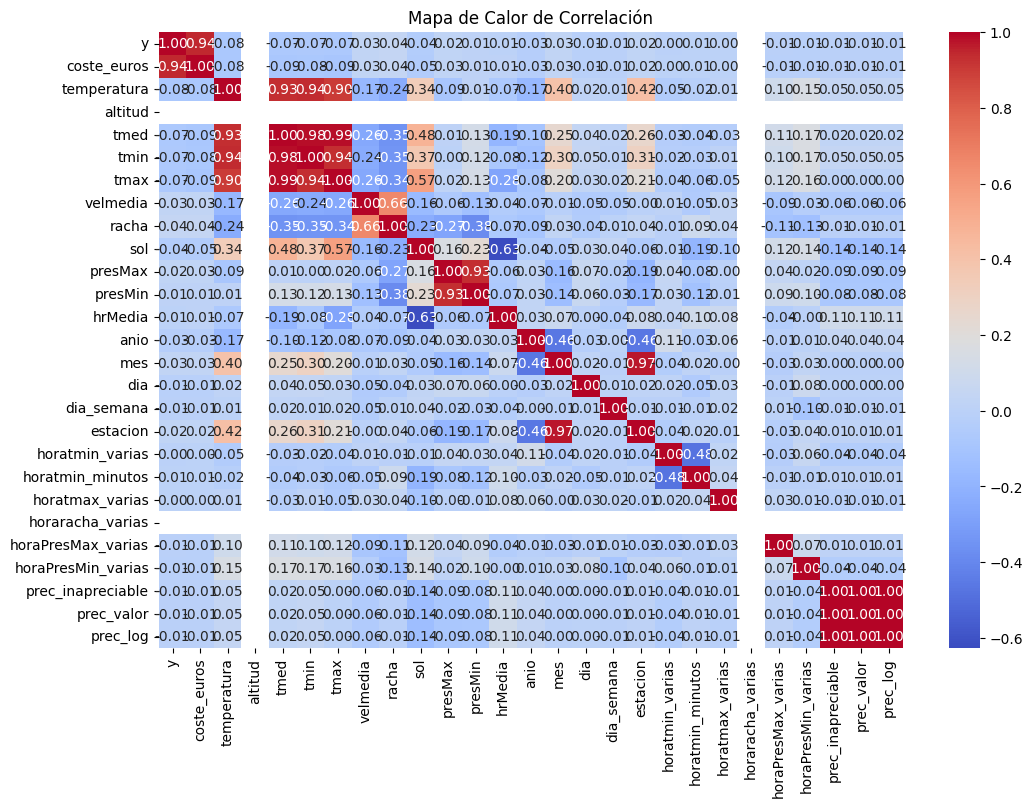

In [ ]:
# Mapa de correlación
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación')
plt.show()

# Creación del Dataset para el Modelo Prophet
En esta sección, seleccionaremos las variables relevantes y crearemos un nuevo dataset para el modelo Prophet.

In [3]:
# Seleccionar las variables relevantes
variables_seleccionadas = ['ds', 'y', 'temperatura', 'coste_euros','tmin', 'tmax', 'velmedia','sol','racha','prec_log']
df_seleccionado = df[variables_seleccionadas].copy()

# Enriquecimiento del Dataset con Regresores
En esta sección, agregaremos medias móviles, tendencias, lags, día de la semana, fines de semana y festivos al dataset.

## LAGS

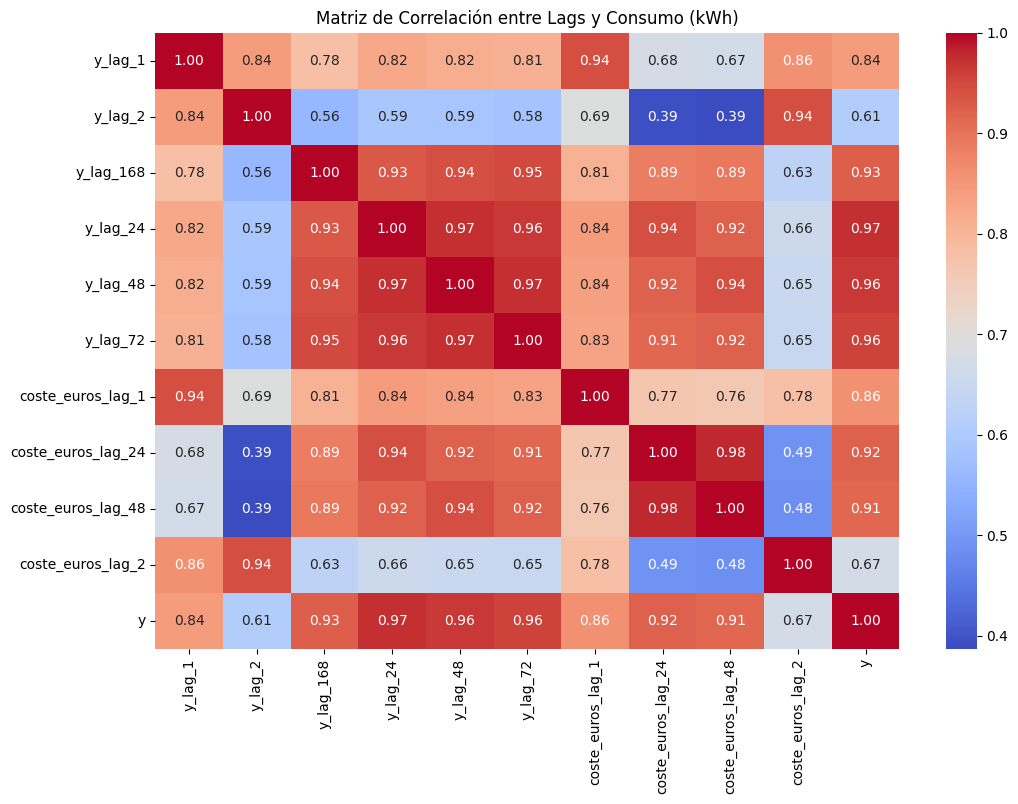

In [5]:
df_seleccionado['y_lag_1'] = df_seleccionado['y'].shift(1)
df_seleccionado['y_lag_2'] = df_seleccionado['y'].shift(2)
# df_seleccionado['y_lag_3'] = df_seleccionado['y'].shift(3)

#lag semana pasada en horas
df_seleccionado['y_lag_168'] = df_seleccionado['y'].shift(168)

#lag de 24 horas
df_seleccionado['y_lag_24'] = df_seleccionado['y'].shift(24)
df_seleccionado['y_lag_48'] = df_seleccionado['y'].shift(48)
df_seleccionado['y_lag_72'] = df_seleccionado['y'].shift(72)

# Crear lags para coste_euros
df_seleccionado['coste_euros_lag_1'] = df_seleccionado['coste_euros'].shift(1)
df_seleccionado['coste_euros_lag_2'] = df_seleccionado['coste_euros'].shift(2)
# df_seleccionado['coste_euros_lag_3'] = df_seleccionado['coste_euros'].shift(3)
df_seleccionado['coste_euros_lag_24'] = df_seleccionado['coste_euros'].shift(24)
df_seleccionado['coste_euros_lag_48'] = df_seleccionado['coste_euros'].shift(48)
lag_columns = [col for col in df_seleccionado.columns if 'lag' in col] + ['y']

#crea una matriz de correlacion entre las variables lags y la variable y
correlation_matrix = df_seleccionado[lag_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags y Consumo (kWh)')
plt.show()


## MEDIAS MOVILES Y TREND

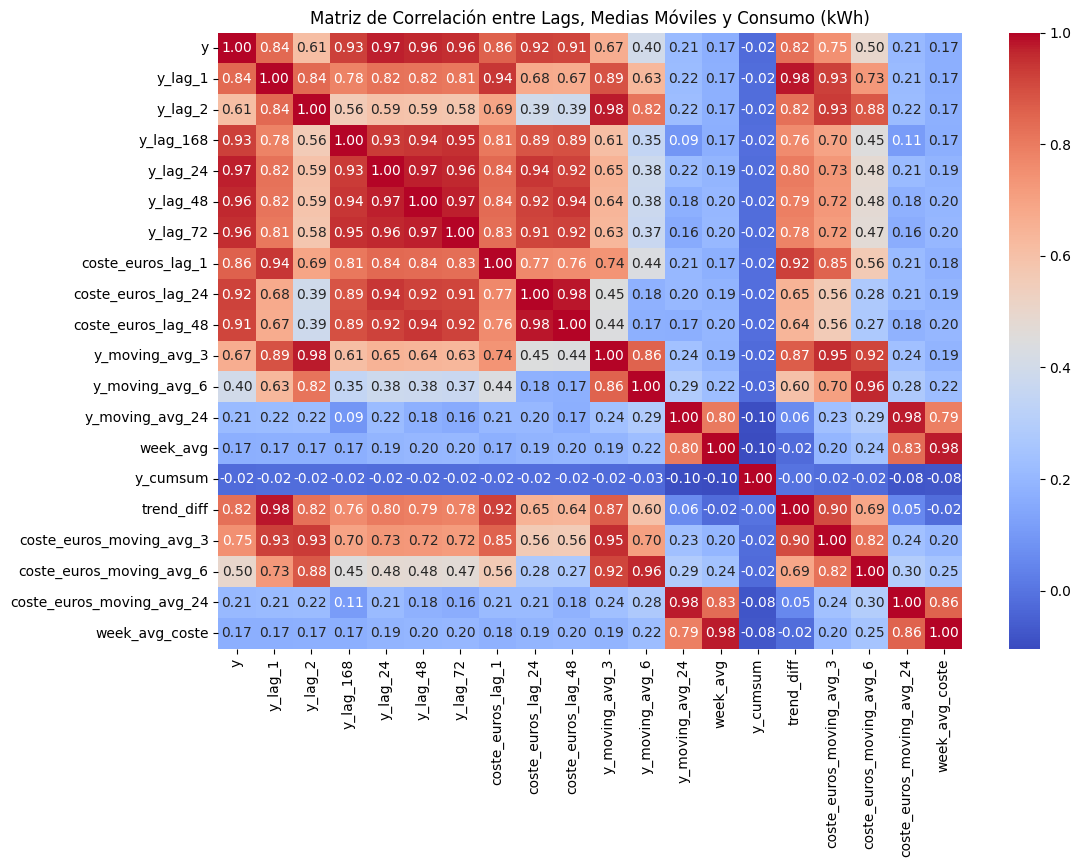

In [7]:
#generar medias moviles para la variable y
df_seleccionado['y_moving_avg_3'] = df_seleccionado['y'].shift(1).rolling(3).mean()
df_seleccionado['y_moving_avg_6'] = df_seleccionado['y'].shift(1).rolling(6).mean()   
df_seleccionado['y_moving_avg_24'] = df_seleccionado['y'].shift(1).rolling(24).mean()  

df_seleccionado['coste_euros_moving_avg_3'] = df_seleccionado['coste_euros'].shift(1).rolling(3).mean()
df_seleccionado['coste_euros_moving_avg_6'] = df_seleccionado['coste_euros'].shift(1).rolling(6).mean()
df_seleccionado['coste_euros_moving_avg_24'] = df_seleccionado['coste_euros'].shift(1).rolling(24).mean()


df_seleccionado['week_avg'] = df_seleccionado['y'].shift(1).rolling(168).mean()
df_seleccionado['week_avg_coste'] = df_seleccionado['coste_euros'].shift(1).rolling(168).mean()

# Calcular tendencia acumulativa para y
df_seleccionado['y_cumsum'] = df_seleccionado['y'].shift(1).cumsum()

df_seleccionado['trend_diff'] = df_seleccionado['y'].shift(1) - df_seleccionado['week_avg']

correlation_matrix = df_seleccionado[['y', 'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 'y_lag_72',
                                        'coste_euros_lag_1', 'coste_euros_lag_24', 'coste_euros_lag_48',
                                        'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
                                        'week_avg', 'y_cumsum','trend_diff',
                                        'coste_euros_moving_avg_3','coste_euros_moving_avg_6','coste_euros_moving_avg_24','week_avg_coste']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()


## DIAS Y FESTIVOS

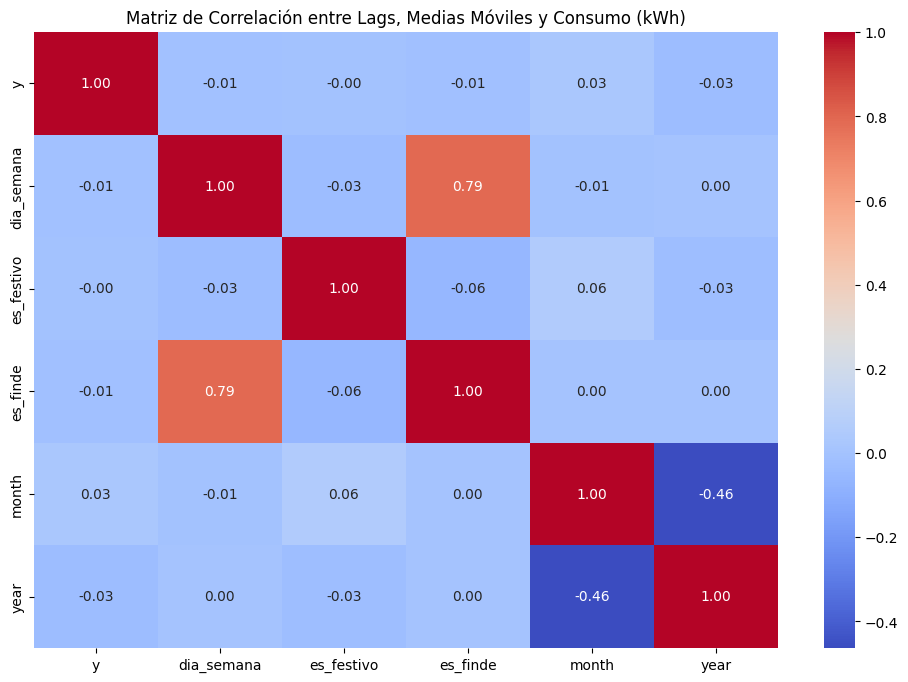

In [8]:
df_seleccionado['dia_semana'] = pd.to_datetime(df_seleccionado['ds']).dt.dayofweek
df_seleccionado['es_finde'] = df_seleccionado['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

# agregar festivos de catalunya
catalunya_holidays = holidays.Spain(years=[2017, 2018, 2019, 2020, 2021, 2022, 2023], subdiv='CT')
df_seleccionado['es_festivo'] = df_seleccionado['ds'].apply(lambda x: 1 if pd.to_datetime(x).date() in catalunya_holidays else 0)
df_seleccionado['year'] =  pd.to_datetime(df_seleccionado['ds']).dt.year
df_seleccionado['month'] =  pd.to_datetime(df_seleccionado['ds']).dt.month

correlation_matrix = df_seleccionado[['y','dia_semana','es_festivo','es_finde', 'month','year']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()



In [9]:

df_seleccionado.dropna(inplace=True)
df_seleccionado.head()

,ds,y,temperatura,coste_euros,tmin,tmax,velmedia,sol,racha,prec_log,...,coste_euros_moving_avg_24,week_avg,week_avg_coste,y_cumsum,trend_diff,dia_semana,es_finde,es_festivo,year,month
168,2018-10-08 00:00:00,2.120,16.52,0.335320,12.5,18.8,1.4,1.9,10.3,0.0,...,0.312836,1.656423,0.303809,278.279,0.429577,0,0,0,2018,10
169,2018-10-08 01:00:00,2.126,16.18,0.316115,12.5,18.8,1.4,1.9,10.3,0.0,...,0.312816,1.669006,0.305799,280.399,0.450994,0,0,0,2018,10
170,2018-10-08 02:00:00,2.123,16.37,0.296328,12.5,18.8,1.4,1.9,10.3,0.0,...,0.312308,1.681619,0.307674,282.525,0.444381,0,0,0,2018,10
171,2018-10-08 03:00:00,2.183,16.28,0.294225,12.5,18.8,1.4,1.9,10.3,0.0,...,0.312006,1.694220,0.309433,284.648,0.428780,0,0,0,2018,10
172,2018-10-08 04:00:00,2.134,16.00,0.312396,12.5,18.8,1.4,1.9,10.3,0.0,...,0.312303,1.707173,0.311179,286.831,0.475827,0,0,0,2018,10


# Modelo Prophet con Cross-Validation
En esta sección, crearemos un modelo Prophet utilizando las variables del dataset, realizaremos un cross-validation y evaluaremos las métricas de rendimiento.

In [10]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [12]:
df_seleccionado.to_csv("df_seleccionado_7.csv", index=False)

In [13]:
# Cargar el dataset seleccionado
df = pd.read_csv('df_seleccionado_7.csv')

In [33]:
# Dividir en prueba 2 semanas y entrenamiento el resto
train = df[:-336]  # Entrenamiento: todo menos las últimas 2 semanas (336 horas)
test = df[-336:]  # Prueba: últimas 2 semanas (336 horas)

In [17]:

regresores = ['temperatura', 'velmedia', 'sol', 'racha', 'prec_log',
             'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 'y_lag_72',
             'coste_euros_lag_1','coste_euros_lag_2', 'coste_euros_lag_24', 'coste_euros_lag_48',
             'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
             'week_avg', 'trend_diff', 
             'coste_euros_moving_avg_3','coste_euros_moving_avg_6','coste_euros_moving_avg_24']



In [18]:
from itertools import product


param_grid = {                       
    'changepoint_prior_scale': [0.05],
    'seasonality_prior_scale': [3],
    'seasonality_mode': ['additive'],
    'changepoint_range': [0.9],
    'n_changepoints': [10],
}

# Combinaciones del grid
all_params = [
    dict(zip(param_grid.keys(), v))
    for v in product(*param_grid.values())
]


In [19]:
results = []            

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        **params
    )

    
    for reg in regresores:
        m.add_regressor(reg)
    m.add_seasonality('daily',  period=1, fourier_order=15)
    m.add_seasonality('weekly', period=7, fourier_order=10)
    m.add_seasonality('monthly', period=30.5, fourier_order=5)
    m.add_seasonality('yearly', period=365.25, fourier_order=5)

    m.fit(df)

    cv = cross_validation(
        m,
        initial='400 days',
        period='24 hours',
        horizon='24 hours'
    )
    perf = performance_metrics(cv, rolling_window=1)   
    results.append({
        **params,
        'rmse': perf['rmse'].mean(),
        'mape': perf['mdape'].mean(),
        'mae': perf['mae'].mean(),
        'mse': perf['mse'].mean(),
        'coverage': perf['coverage'].mean()
    })

cv_grid_3 = pd.DataFrame(results).sort_values('rmse')
print(cv_grid_3.head())

17:12:55 - cmdstanpy - INFO - Chain [1] start processing
17:12:59 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/550 [00:00<?, ?it/s]17:13:06 - cmdstanpy - INFO - Chain [1] start processing
17:13:12 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/550 [00:06<1:03:23,  6.93s/it]17:13:13 - cmdstanpy - INFO - Chain [1] start processing
17:13:17 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 2/550 [00:12<53:34,  5.87s/it]  17:13:18 - cmdstanpy - INFO - Chain [1] start processing
17:13:23 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 3/550 [00:17<53:42,  5.89s/it]17:13:24 - cmdstanpy - INFO - Chain [1] start processing
17:13:29 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 4/550 [00:24<54:39,  6.01s/it]17:13:30 - cmdstanpy - INFO - Chain [1] start processing
17:13:36 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 5/550 [00:30<56:03,  6.17s/it]17:13:36 - cmdstanpy - INFO - Chain [1] star

   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                        3         additive   

   changepoint_range  n_changepoints      rmse      mape      mae       mse  \
0                0.9              10  0.133103  0.029885  0.05159  0.017716   

   coverage  
0  0.944853  


In [20]:
cv_grid = pd.DataFrame(results).sort_values('rmse')
print(cv_grid.head())

   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                        3         additive   

   changepoint_range  n_changepoints      rmse      mape      mae       mse  \
0                0.9              10  0.133103  0.029885  0.05159  0.017716   

   coverage  
0  0.944853  


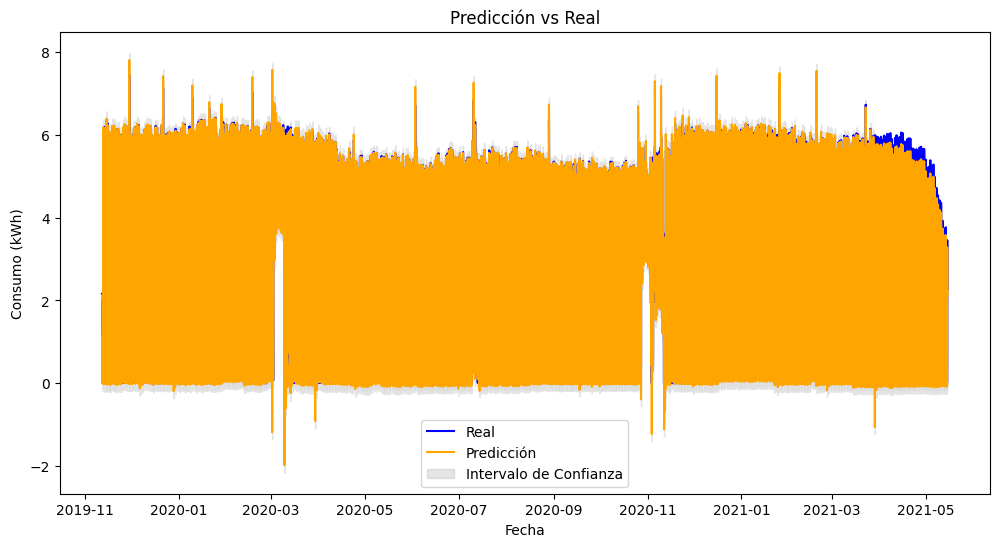

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(cv['ds'], cv['y'], label='Real', color='blue')
plt.plot(cv['ds'], cv['yhat'], label='Predicción', color='orange')
plt.fill_between(cv['ds'], cv['yhat_lower'], cv['yhat_upper'], color='gray', alpha=0.2, label='Intervalo de Confianza')
plt.title('Predicción vs Real')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.show()

In [22]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'
fig = go.Figure()
fig.add_trace(go.Scatter(x=cv['ds'], y=cv['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=cv['ds'], y=cv['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real (Interactividad)',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')

In [23]:
#hazme un grafico de la variable predicha y valor real que sea interactivo pero para solo 3 dias
# Filtrar los resultados para los últimos 3 días
last_3_days = cv[cv['ds'] >= (cv['ds'].max() - pd.Timedelta(days=120))].copy()
# Crear gráfico interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')
fig.show()


In [26]:
joblib.dump(m, "modelo_prophet.pkl")



['modelo_prophet.pkl']

# Generación de Dataset Futuro y Predicciones
En esta sección, generaremos un dataset futuro con todas las variables regresoras necesarias y realizaremos predicciones para los próximos 3 días.

In [34]:
# Cargar el modelo guardado
loaded_model = joblib.load("modelo_prophet.pkl")
# El dataframe futuro tenemos los datos del test
future = test[['ds']].copy()
# Agregar regresores al dataframe futuro
for reg in regresores:
    future[reg] = test[reg].values
# Realizar la predicción
forecast = loaded_model.predict(future)
# Mostrar las predicciones
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(336)
# Filtrar los resultados para los últimos 3 días
last_3_days = forecast[forecast['ds'] >= (forecast['ds'].max() - pd.Timedelta(days=120))].copy()
# Crear gráfico interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=test['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.update_layout(title='Predicción vs Real (Interactividad)',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')
# Mostrar el gráfico